## import libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Optimization
from pyswarm import pso
from mealpy import FloatVar
from mealpy.swarm_based.GWO import OriginalGWO
from mealpy.physics_based.MVO import OriginalMVO

## Data preparation

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df =pd.read_csv('/content/drive/MyDrive/coding_data/smoking.csv')
df.head(10)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0
5,5,M,30,180,75,85.0,1.2,1.2,1.0,1.0,...,16.2,1.0,1.2,18.0,27.0,33.0,Y,0,Y,0
6,6,M,40,160,60,85.5,1.0,1.0,1.0,1.0,...,17.0,1.0,0.7,21.0,27.0,39.0,Y,1,Y,1
7,7,M,45,165,90,96.0,1.2,1.0,1.0,1.0,...,15.0,1.0,1.3,38.0,71.0,111.0,Y,0,Y,0
8,9,F,50,150,60,85.0,0.7,0.8,1.0,1.0,...,13.7,1.0,0.8,31.0,31.0,14.0,Y,0,N,0
9,10,M,45,175,75,89.0,1.0,1.0,1.0,1.0,...,16.0,1.0,0.8,26.0,24.0,63.0,Y,0,N,0


In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55692 entries, 0 to 55691
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   55692 non-null  int64  
 1   gender               55692 non-null  object 
 2   age                  55692 non-null  int64  
 3   height(cm)           55692 non-null  int64  
 4   weight(kg)           55692 non-null  int64  
 5   waist(cm)            55692 non-null  float64
 6   eyesight(left)       55692 non-null  float64
 7   eyesight(right)      55692 non-null  float64
 8   hearing(left)        55692 non-null  float64
 9   hearing(right)       55692 non-null  float64
 10  systolic             55692 non-null  float64
 11  relaxation           55692 non-null  float64
 12  fasting blood sugar  55692 non-null  float64
 13  Cholesterol          55692 non-null  float64
 14  triglyceride         55692 non-null  float64
 15  HDL                  55692 non-null 

In [8]:
df.describe()

,ID,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,...,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000,55692.000000
mean,27845.500000,44.182917,164.649321,65.864936,82.046418,1.012623,1.007443,1.025587,1.026144,121.494218,...,57.290347,114.964501,14.622592,1.087212,0.885738,26.182935,27.036037,39.952201,0.213334,0.367288
std,16077.039933,12.071418,9.194597,12.820306,9.274223,0.486873,0.485964,0.157902,0.159564,13.675989,...,14.738963,40.926476,1.564498,0.404882,0.221524,19.355460,30.947853,50.290539,0.409665,0.482070
min,0.000000,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,1.000000,0.000000,0.000000
25%,13922.750000,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,...,47.000000,92.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,27845.500000,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,25.000000,0.000000,0.000000
75%,41768.250000,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,...,66.000000,136.000000,15.800000,1.000000,1.000000,28.000000,31.000000,43.000000,0.000000,1.000000
max,55691.000000,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.000000,2.000000,240.000000,...,618.000000,1860.000000,21.100000,6.000000,11.600000,1311.000000,2914.000000,999.000000,1.000000,1.000000


In [ ]:
df =df.drop(['ID'], axis=1)
df

,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,114.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,119.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,138.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,100.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,120.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55687,F,40,170,65,75.0,0.9,0.9,1.0,1.0,110.0,...,12.3,1.0,0.6,14.0,7.0,10.0,Y,1,Y,0
55688,F,45,160,50,70.0,1.2,1.2,1.0,1.0,101.0,...,14.0,1.0,0.9,20.0,12.0,14.0,Y,0,Y,0
55689,F,55,160,50,68.5,1.0,1.2,1.0,1.0,117.0,...,12.4,1.0,0.5,17.0,11.0,12.0,Y,0,N,0
55690,M,60,165,60,78.0,0.8,1.0,1.0,1.0,133.0,...,14.4,1.0,0.7,20.0,19.0,18.0,Y,0,N,0


In [9]:
le = LabelEncoder()
for column in df.columns:
  if df[column].dtype == 'object':
    df[column] = le.fit_transform(df[column])

df.head(10)

# 0 > femal
# 1 > male

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,0,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,0,0,1,0
1,1,0,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,0,0,1,0
2,2,1,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,0,0,0,1
3,3,1,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,0,0,1,0
4,4,0,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,0,0,0,0
5,5,1,30,180,75,85.0,1.2,1.2,1.0,1.0,...,16.2,1.0,1.2,18.0,27.0,33.0,0,0,1,0
6,6,1,40,160,60,85.5,1.0,1.0,1.0,1.0,...,17.0,1.0,0.7,21.0,27.0,39.0,0,1,1,1
7,7,1,45,165,90,96.0,1.2,1.0,1.0,1.0,...,15.0,1.0,1.3,38.0,71.0,111.0,0,0,1,0
8,9,0,50,150,60,85.0,0.7,0.8,1.0,1.0,...,13.7,1.0,0.8,31.0,31.0,14.0,0,0,0,0
9,10,1,45,175,75,89.0,1.0,1.0,1.0,1.0,...,16.0,1.0,0.8,26.0,24.0,63.0,0,0,0,0


In [10]:
# for col in df.columns:
#   if col != 'smoking':
#     sns.histplot(df[col], kde=True)
#     plt.show()

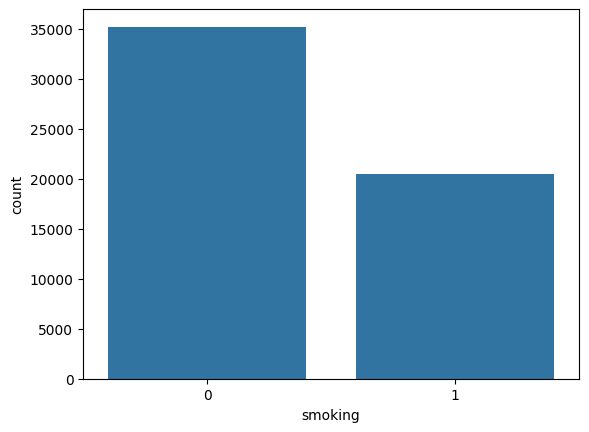

In [11]:
sns.countplot( x = 'smoking', data=df)
plt.show()

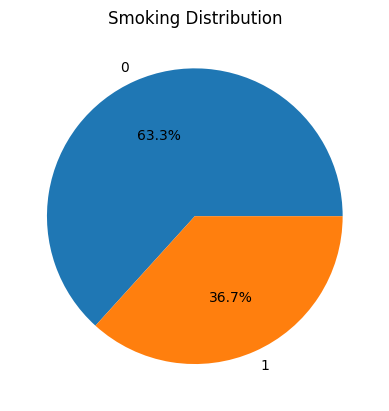

In [12]:
plt.pie(df['smoking'].value_counts(), labels=df['smoking'].unique(), autopct='%1.1f%%')
plt.title('Smoking Distribution')
plt.show()

In [13]:
x = df.drop('smoking', axis=1)
y = df['smoking']

In [14]:
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X, y)

In [15]:
x_train , X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (55692, 27)


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,0,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,0,0,1,0
1,1,0,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,0,0,1,0
2,2,1,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,0,0,0,1
3,3,1,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,0,0,1,0
4,4,0,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,0,0,0,0


# XGBClassifier

Befor **PSOGSA** Optmization



In [25]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)
y_pred = xgb.predict(X_test)


print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted')*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted')*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted')*100:.2f}%")

Accuracy: 77.47%
Recall: 77.47%
Precision: 77.64%
F1 Score: 77.54%


After **PSOGSA** Optmization

In [38]:
def fitness_xgb(solution):
    n_estimators = int(solution[0])
    max_depth = int(solution[1])
    learning_rate = solution[2]

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )


    scores = cross_val_score(model, x_train, y_train, cv=2)
    return np.mean(scores)

problem_dict_xgb = {
    "obj_func": fitness_xgb,
    "bounds": FloatVar(lb=[50, 3, 0.01], ub=[150, 7, 0.2]),
    "minmax": "max",
}

model_mvo = OriginalMVO(epoch=5, pop_size=5)
g_best_xgb = model_mvo.solve(problem_dict_xgb)

INFO:mealpy.physics_based.MVO.OriginalMVO:OriginalMVO(epoch=5, pop_size=5, wep_min=0.2, wep_max=1.0)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:32:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:32:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:32:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:32:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  b

In [39]:
best_params = g_best_xgb.solution
final_xgb = XGBClassifier(
    n_estimators=int(best_params[0]),
    max_depth=int(best_params[1]),
    learning_rate=best_params[2],
    use_label_encoder=False,
    eval_metric='logloss'
)
final_xgb.fit(x_train, y_train)
y_pred_xgb = final_xgb.predict(X_test)

print("\n=== XGBoost + MVO Performance ===")
print(f"Best Parameters: n_estimators={int(best_params[0])}, max_depth={int(best_params[1])}, LR={best_params[2]:.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_xgb, average='weighted')*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_xgb, average='weighted')*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb, average='weighted')*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:33:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost + MVO Performance ===
Best Parameters: n_estimators=148, max_depth=7, LR=0.2000
Accuracy:  78.85%
Recall:    78.85%
Precision: 78.98%
F1 Score:  78.91%


In [41]:


# ── Settings ──
N_AGENTS = 8
N_ITERS  = 10
DIM = 3

W  = 0.5
C1 = 1.5
G0 = 100
ALPHA = 20

# ── Bounds: [n_estimators, max_depth, learning_rate] ──
BOUNDS = np.array([
    [50, 300],     # n_estimators
    [3,  10],      # max_depth
    [0.01, 0.3]    # learning_rate
])

# ── Objective Function ──
def xgb_objective(params):
    n_est = int(round(params[0]))
    depth = int(round(params[1]))
    lr    = float(params[2])

    model = XGBClassifier(
        n_estimators=n_est,
        max_depth=depth,
        learning_rate=lr,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    score = cross_val_score(model, x_train, y_train, cv=3, scoring='f1').mean()
    return score

# ── Initialize Agents ──
pos = np.random.uniform(BOUNDS[:, 0], BOUNDS[:, 1], (N_AGENTS, DIM))
vel = np.zeros_like(pos)

best_score = -np.inf
best_pos = None
history = []

print("PSOGSA Optimization for XGBoost")

for t in range(N_ITERS):

    # Evaluate fitness
    fitness = np.array([xgb_objective(p) for p in pos])

    worst = np.min(fitness)
    best  = np.max(fitness)

    # Mass calculation
    if best == worst:
        mass = np.ones(N_AGENTS) / N_AGENTS
    else:
        mass = (fitness - worst) / (best - worst)
        mass = mass / mass.sum()

    # Update best
    if best > best_score:
        best_score = best
        best_pos = pos[np.argmax(fitness)].copy()

    # Gravitational constant
    G = G0 * np.exp(-ALPHA * t / N_ITERS)

    acc = np.zeros_like(pos)

    # Compute forces
    for i in range(N_AGENTS):
        for j in range(N_AGENTS):
            if i != j:
                dist = np.linalg.norm(pos[j] - pos[i]) + 1e-6
                force = G * (mass[i] * mass[j]) * (pos[j] - pos[i]) / dist
                acc[i] += force

    # Update velocity (PSO + GSA)
    r1 = np.random.rand(N_AGENTS, DIM)
    vel = W * vel + C1 * r1 * (best_pos - pos) + acc

    # Update position
    pos = pos + vel
    pos = np.clip(pos, BOUNDS[:, 0], BOUNDS[:, 1])

    history.append(best_score)

    print(f"Iter {t+1}: Best F1 = {best_score:.4f}")

# Best Parameters
best_xgb_params = {
    'n_estimators': int(round(best_pos[0])),
    'max_depth': int(round(best_pos[1])),
    'learning_rate': float(best_pos[2])
}

print("\nBest Params:", best_xgb_params)
print("Best CV F1:", best_score)

PSOGSA Optimization for XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:37:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:37:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:37:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:37:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Iter 1: Best F1 = 0.7310


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Iter 2: Best F1 = 0.7314


...

Iter 8: Best F1 = 0.7337


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:48:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:48:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:48:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:48:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Iter 9: Best F1 = 0.7337


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Iter 10: Best F1 = 0.7337

Best Params: {'n_estimators': 261, 'max_depth': 10, 'learning_rate': 0.08380695906095571}
Best CV F1: 0.7336926096933826


In [42]:
xgb_best = XGBClassifier(
    **best_xgb_params,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_best.fit(x_train, y_train)

y_pred = xgb_best.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted')*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted')*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted')*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:51:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 81.49%
Recall: 81.49%
Precision: 81.64%
F1 Score: 81.55%


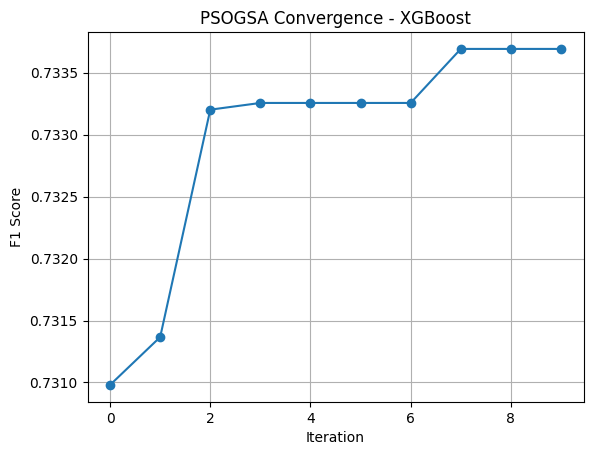

In [43]:
plt.plot(history, marker='o')
plt.title("PSOGSA Convergence - XGBoost")
plt.xlabel("Iteration")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

# SVM

In [17]:
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted')*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted')*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted')*100:.2f}%")

Accuracy: 76.00%
Recall: 76.00%
Precision: 76.56%
F1 Score: 76.20%


**After_GWO**

In [18]:
def fitness_function(solution):
    C_val, gamma_val = solution
    model = SVC(C=C_val, gamma=gamma_val, max_iter=1000)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=3)
    return np.mean(scores)


problem_dict = {
    "obj_func": fitness_function,
    "bounds": FloatVar(lb=[0.1, 0.0001], ub=[100, 1.0]),
    "minmax": "max",
}


model_gwo = OriginalGWO(epoch=5, pop_size=10)
g_best = model_gwo.solve(problem_dict)

print(f"Best Solution (C, Gamma): {g_best.solution}")
print(f"Best Accuracy: {g_best.target.fitness}")

INFO:mealpy.swarm_based.GWO.OriginalGWO:OriginalGWO(epoch=5, pop_size=10)
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:3

Best Solution (C, Gamma): [52.36332329  0.20353021]
Best Accuracy: 0.6566561174331694


In [21]:
best_c = g_best.solution[0]
best_gamma = g_best.solution[1]

final_svm = SVC(C=best_c, gamma=best_gamma)
final_svm.fit(X_train_scaled, y_train)
y_pred_svm = final_svm.predict(X_test_scaled)

print("=== SVM Optimized (GWO) Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred_svm, average='weighted')*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='weighted')*100:.2f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_svm, average='weighted')*100:.2f}%")

=== SVM Optimized (GWO) Performance ===
Accuracy:  78.40%
Recall:    78.40%
Precision: 78.20%
F1 Score:  78.26%
